In [391]:
import numpy

In [392]:
words = [w for w in open('names.txt', 'r').read().splitlines()]  

In [393]:
import torch

In [394]:
N = torch.zeros((27,27), dtype= torch.int32)

In [395]:
chars = sorted(list(set(''.join(words))))
stoi = {s:i+1 for i, s in enumerate(chars)}
stoi['.'] = 0
itos= {i:s for s, i in stoi.items()}


In [396]:
for w in words:
    chs = ['.'] + list(w) + ['.']
    for ch1, ch2 in zip(chs, chs[1:]):
        ix1 = stoi[ch1]
        ix2 = stoi[ch2]
        N[ix1, ix2] += 1

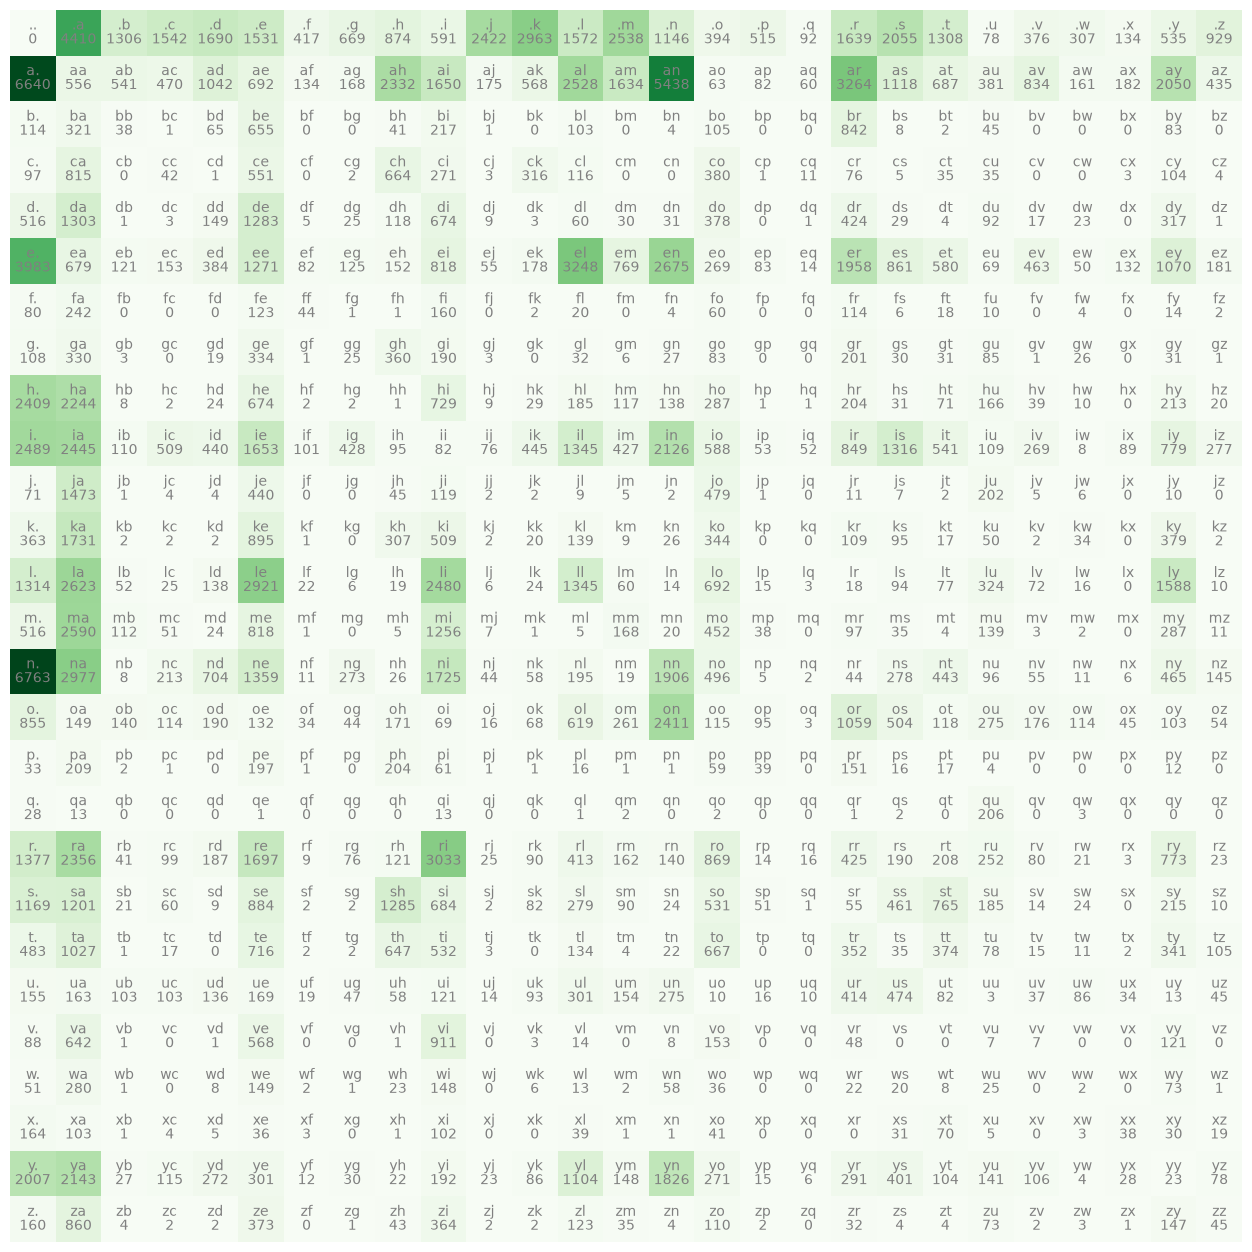

In [397]:
import matplotlib.pyplot as plt
%matplotlib inline

plt.figure(figsize=(16,16))
plt.imshow(N, cmap='Greens')
for i in range(27):
    for j in range(27):
        chstr = itos[i] + itos[j]
        plt.text(j, i, chstr, ha="center", va="bottom", color='gray')
        plt.text(j, i, N[i, j].item(), ha="center", va="top", color='gray')
plt.axis('off');   

In [398]:
N[0]

tensor([   0, 4410, 1306, 1542, 1690, 1531,  417,  669,  874,  591, 2422, 2963,
        1572, 2538, 1146,  394,  515,   92, 1639, 2055, 1308,   78,  376,  307,
         134,  535,  929], dtype=torch.int32)

In [399]:
p = N[0].float()
p = p / p.sum() 
p

tensor([0.0000, 0.1377, 0.0408, 0.0481, 0.0528, 0.0478, 0.0130, 0.0209, 0.0273,
        0.0184, 0.0756, 0.0925, 0.0491, 0.0792, 0.0358, 0.0123, 0.0161, 0.0029,
        0.0512, 0.0642, 0.0408, 0.0024, 0.0117, 0.0096, 0.0042, 0.0167, 0.0290])

In [400]:
g = torch.Generator().manual_seed(2147483647)  
ix = torch.multinomial(p, num_samples=2, replacement=True, generator=g)[0].item()
itos[ix]


'm'

In [401]:
g = torch.Generator().manual_seed(2147483647)  
p = torch.rand(3, generator=g)
p = p / p.sum() 

p

tensor([0.6064, 0.3033, 0.0903])

In [402]:
torch.multinomial(p, num_samples=100, replacement=True, generator=g)

tensor([1, 1, 2, 0, 0, 2, 1, 1, 0, 0, 0, 1, 1, 0, 0, 1, 1, 0, 0, 1, 0, 2, 0, 0,
        1, 0, 0, 1, 0, 0, 0, 1, 1, 1, 0, 1, 1, 0, 0, 1, 1, 1, 0, 1, 1, 0, 1, 1,
        0, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0,
        0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 2, 0, 0, 0, 0, 0, 0, 1, 0, 0, 2, 0, 1, 0,
        0, 1, 1, 1])

In [403]:
P= (N+1).float()

In [404]:
# P.sum(1, keepdim=True).shape


In [405]:
P.sum(1).shape

torch.Size([27])

In [406]:
P = (N+1).float()
P /= P.sum(1, keepdims=True)

In [407]:
P[:, 0].sum()

tensor(3.0023)

In [408]:
g = torch.Generator().manual_seed(2147483647)  
out = []
ix = 0 
for i in range(5):
    while True:
        p = N[ix].float()
        p = p / p.sum()
        ix = torch.multinomial(p, num_samples=1, replacement=True, generator=g).item()
        out.append(itos[ix])
        if ix == 0:
            break
    
print(''.join(out))

cexze.momasurailezitynn.konimittain.llayn.ka.


In [409]:
log_likelyhood = 0.0
n=0
for w in ["andrejq"]:
    chs = ['.'] + list(w) + ['.']
    for ch1, ch2 in zip(chs, chs[1:]):
        ix1 = stoi[ch1]
        ix2 = stoi[ch2]
        N[ix1, ix2] += 1
        prob = P[ix1, ix2]
        logprob = torch.log(prob)
        log_likelyhood += logprob
        n+=1
        # print(f'{ch1}{ch2}: {prob: .4f} {logprob: .4f}')
        
nll = -log_likelyhood
print(f'{log_likelyhood= }')
print(f'{nll= }')
print(f'{nll/n= }')


log_likelyhood= tensor(-27.8672)
nll= tensor(27.8672)
nll/n= tensor(3.4834)


In [410]:
# Creating a training set of bigrams and their corresponding next character


xs, ys = [], []
for w in words[:1]:
    chs = ['.'] + list(w) + ['.']
    for ch1, ch2 in zip(chs, chs[1:]):
        ix1 = stoi[ch1]
        ix2 = stoi[ch2]
        print(ch1, ch2)
        xs.append(ix1)
        ys.append(ix2)
xs = torch.tensor(xs)
ys = torch.tensor(ys)


. e
e m
m m
m a
a .


In [411]:
import torch.nn.functional as F


In [412]:
g = torch.Generator().manual_seed(2147483647)
W = torch.randn((27, 27), generator=g, requires_grad=True)

# (5,27) @ (27,27) = (5,27) 
# 27 will multiply and add.

In [413]:
# create the dataset
xs, ys = [], []
for w in words:
  chs = ['.'] + list(w) + ['.']
  for ch1, ch2 in zip(chs, chs[1:]):
    ix1 = stoi[ch1]
    ix2 = stoi[ch2]
    xs.append(ix1)
    ys.append(ix2)
xs = torch.tensor(xs)
ys = torch.tensor(ys)
num = xs.nelement()
print('number of examples: ', num)

# initialize the 'network'
g = torch.Generator().manual_seed(2147483647)
W = torch.randn((27, 27), generator=g, requires_grad=True)

number of examples:  228146


W.exp() === N array of words
W === log count of N array of words


Each character index (e.g. 5 for 'f') becomes a 27-element vector with a single 1 at that position and 0s everywhere else.

index 5 → [0, 0, 0, 0, 0, 1, 0, 0, ..., 0]

F.one_hot(xs, num_classes=27) does this for all inputs at once. If xs = [0, 13, 5, 5, 8] you get a 5×27 matrix where each row is one-hot.

logits = xenc @ W:

Multiplying a one-hot row by W just selects a row of W. Row 0 of xenc picks row 0 of W, row 1 picks row 1, etc. The result is a 5×27 matrix of raw scores (one score per possible next character).

counts = logits.exp():

Exponentiate to turn raw scores into positive "count-like" values (like N matrix).

probs = counts / counts.sum(1, keepdim=True):

Normalize each row so it sums to 1 → valid probability distribution. (This is softmax.)

probs[torch.arange(5), ys]:

Pick out the probability the model assigned to the actual next character (the target) for each of the 5 samples. This is what you take the log of for the loss.

The whole thing is: one-hot → pick a row of W → exp → normalize → read off the target's probability. That's the entire "model" at this stage.

In [416]:
# gradient descent
for k in range(100):
  
  # forward pass
  xenc = F.one_hot(xs, num_classes=27).float() # input to the network: one-hot encoding
  logits = xenc @ W # predict log-counts
  counts = logits.exp() # counts, equivalent to N
  probs = counts / counts.sum(1, keepdims=True) # probabilities for next character
  loss = -probs[torch.arange(num), ys].log().mean() + 0.01*(W**2).mean()
  print(loss.item())
  
  # backward pass
  W.grad = None # set to zero the gradient
  loss.backward()
  
  # update
  W.data += -50 * W.grad
    # N matrix is the count of how many times each bigram occurs in the training 
    # data. The logits are the raw scores produced by the model before applying the
    # softmax function to convert them into probabilities. By exponentiating the logits, we can
    # obtain counts that are proportional to the original counts in the N matrix.


2.4834256172180176
2.4833855628967285
2.4833483695983887
2.4833130836486816
2.4832797050476074
2.4832475185394287
2.4832167625427246
2.483186960220337
2.4831581115722656
2.4831299781799316
2.483103036880493
2.483076333999634
2.483050584793091
2.4830257892608643
2.483001232147217
2.4829773902893066
2.4829540252685547
2.48293137550354
2.4829089641571045
2.4828877449035645
2.482865571975708
2.482844829559326
2.4828243255615234
2.4828040599823
2.4827845096588135
2.482764959335327
2.482745409011841
2.48272705078125
2.48270845413208
2.4826905727386475
2.4826724529266357
2.4826548099517822
2.482637643814087
2.4826204776763916
2.4826037883758545
2.4825870990753174
2.4825706481933594
2.4825544357299805
2.482538938522339
2.482523202896118
2.4825079441070557
2.482492446899414
2.4824774265289307
2.4824624061584473
2.482448101043701
2.482433557510376
2.48241925239563
2.4824047088623047
2.482390880584717
2.482377290725708
2.48236346244812
2.4823503494262695
2.48233699798584
2.48232364654541
2.482310

In [ ]:
# finally, sample from the 'neural net' model
g = torch.Generator().manual_seed(2147483647)

for i in range(5):
  
  out = []
  ix = 0
  while True:
    
    # ----------
    # BEFORE:
    #p = P[ix]
    # ----------
    # NOW:
    xenc = F.one_hot(torch.tensor([ix]), num_classes=27).float()
    logits = xenc @ W # predict log-counts
    counts = logits.exp() # counts, equivalent to N
    p = counts / counts.sum(1, keepdims=True) # probabilities for next character
    # ----------
    
    ix = torch.multinomial(p, num_samples=1, replacement=True, generator=g).item()
    out.append(itos[ix])
    if ix == 0:
      break
  print(''.join(out))

IndexError: Dimension out of range (expected to be in range of [-2, 1], but got 2)